Found 58 file(s). Generating plots...


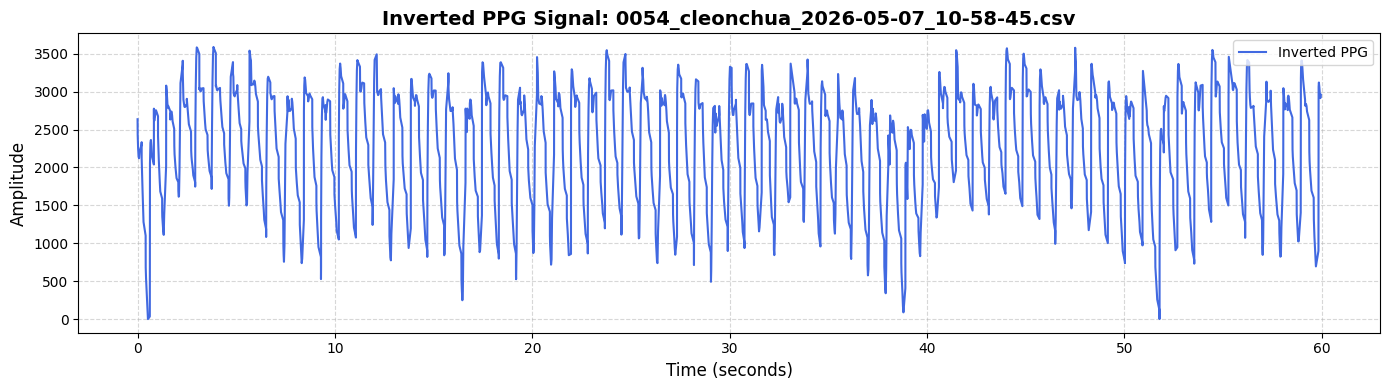

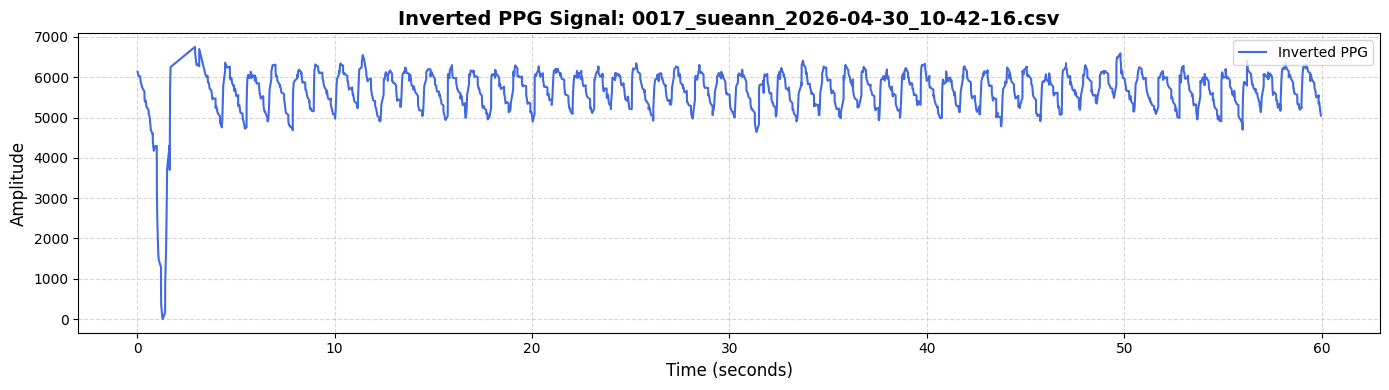

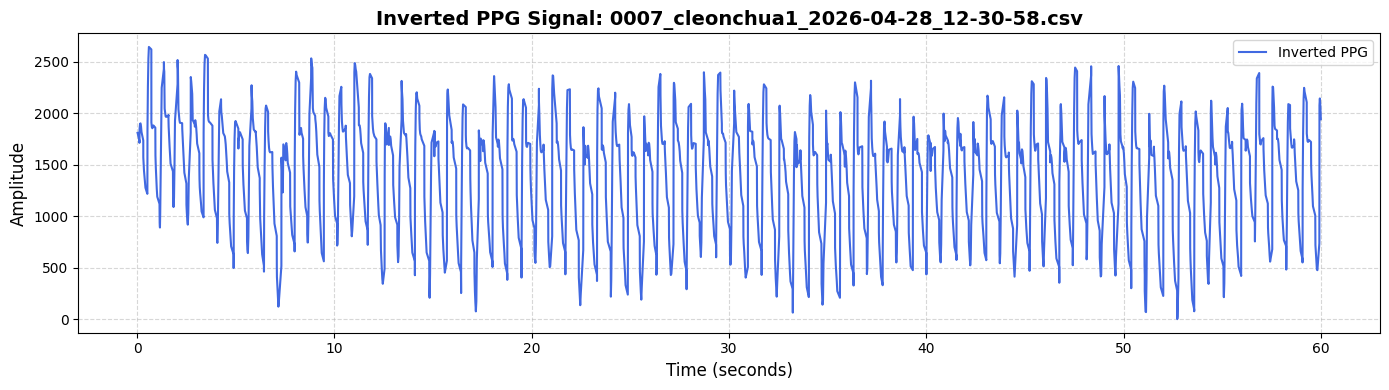

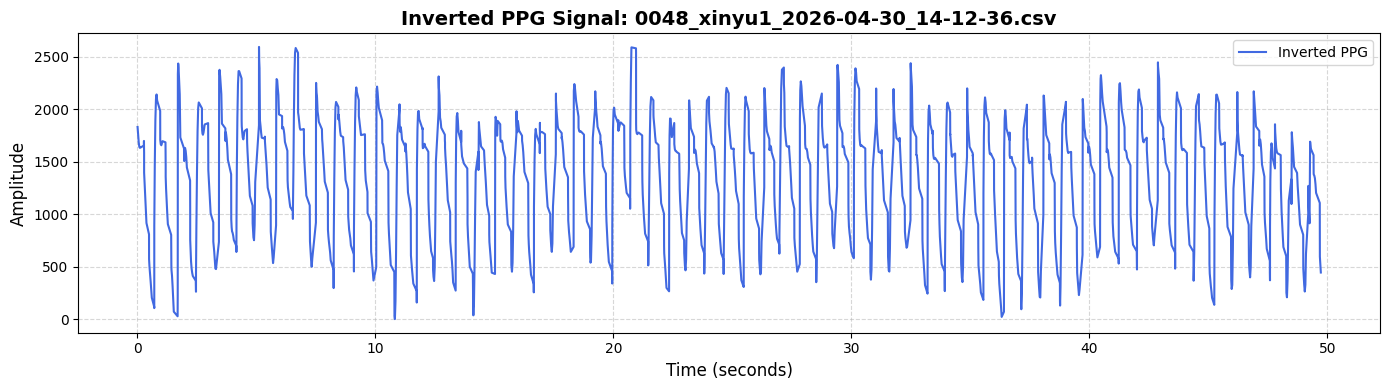

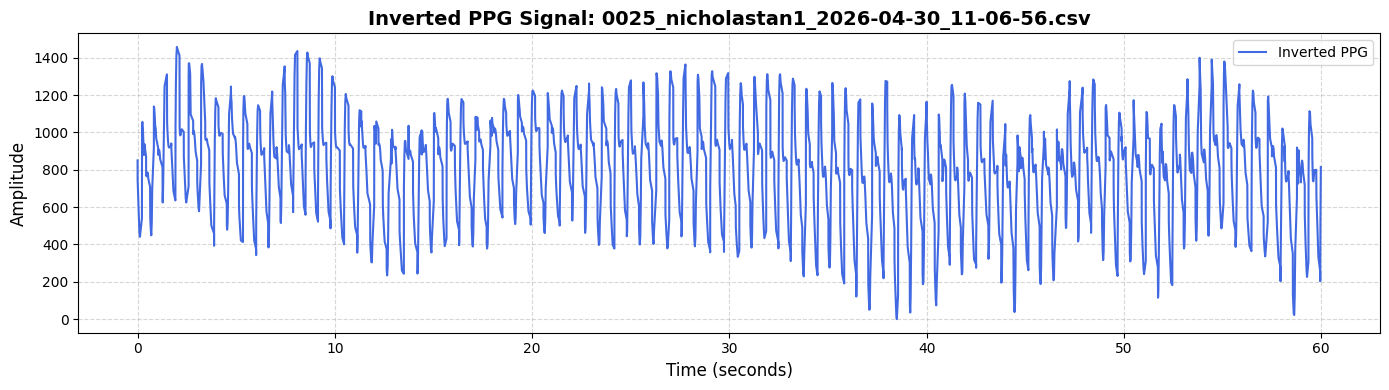

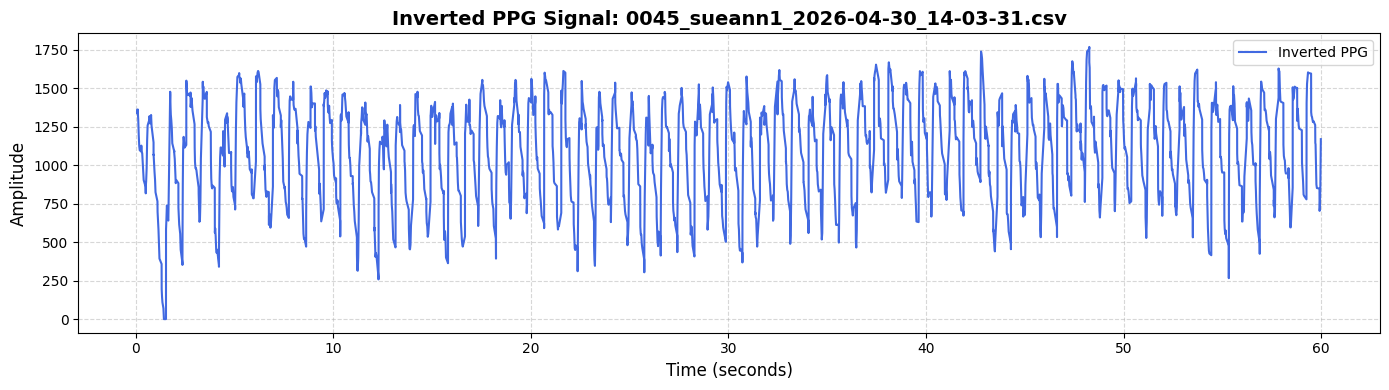

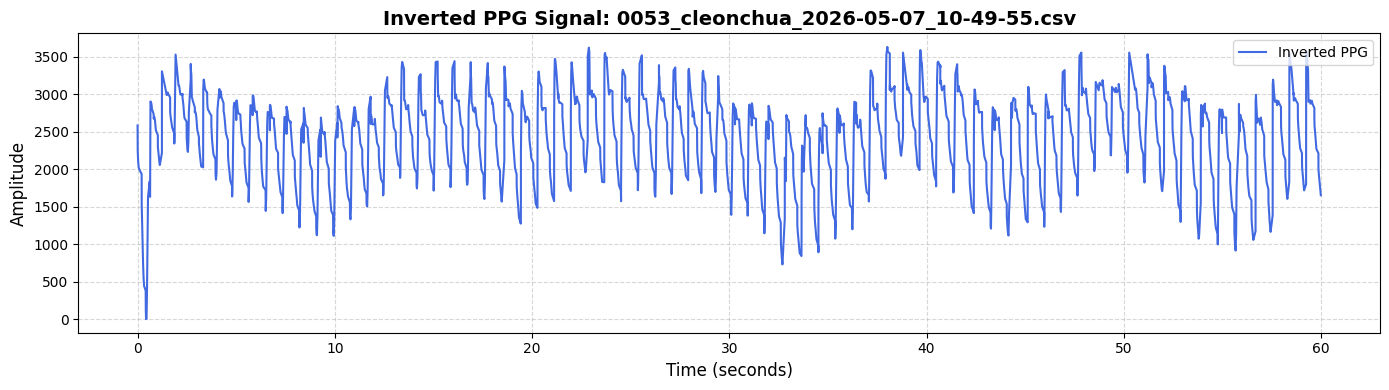

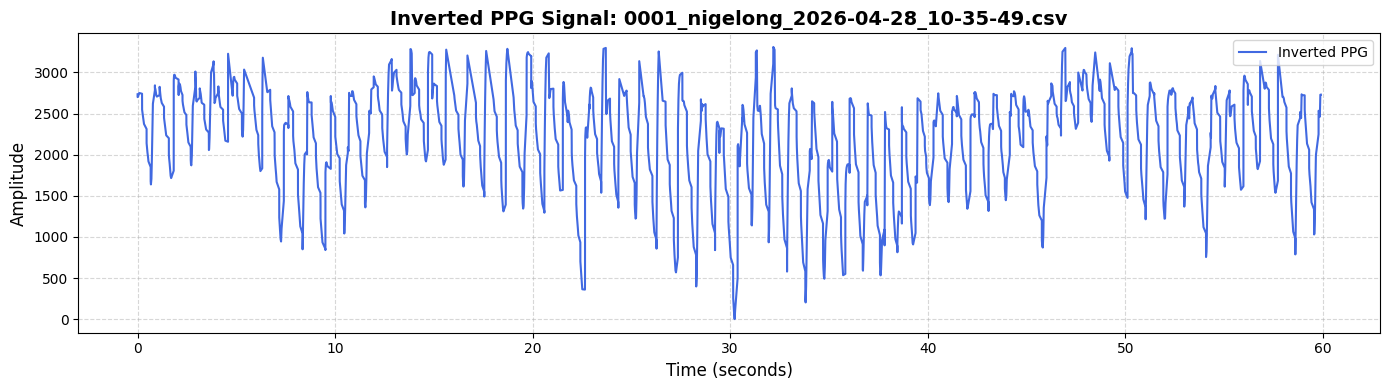

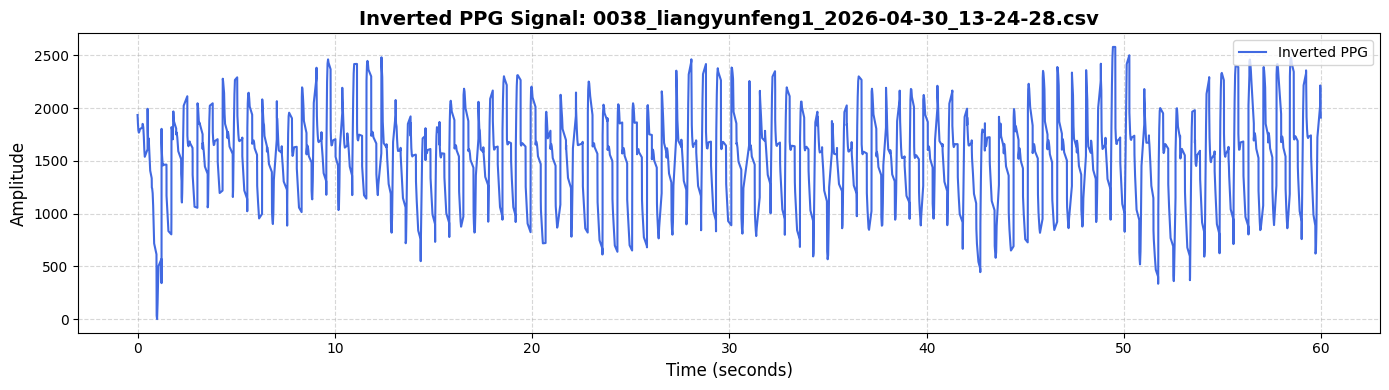

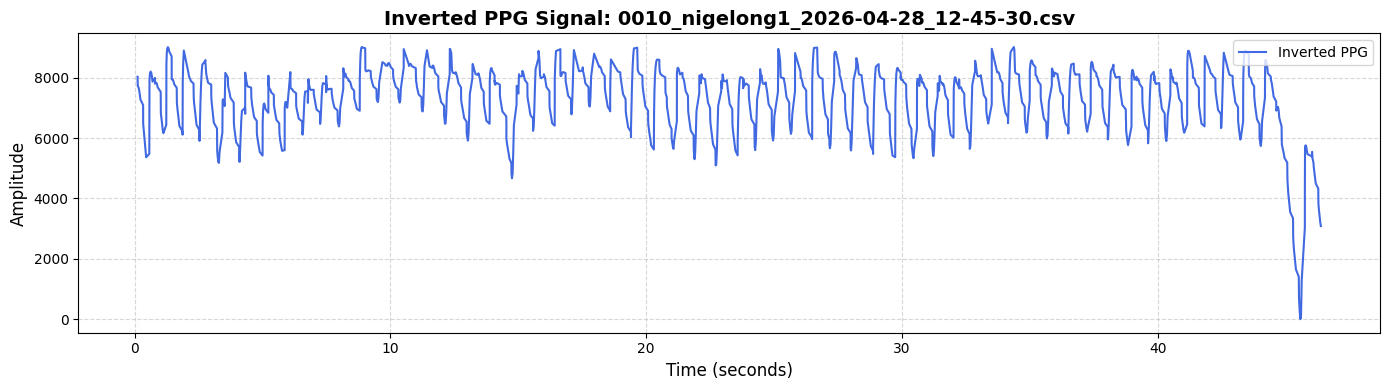

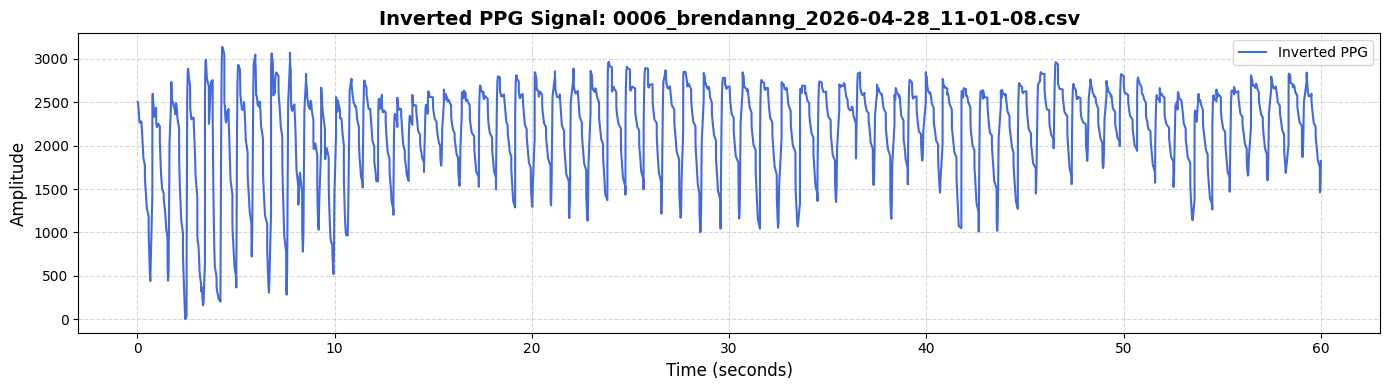

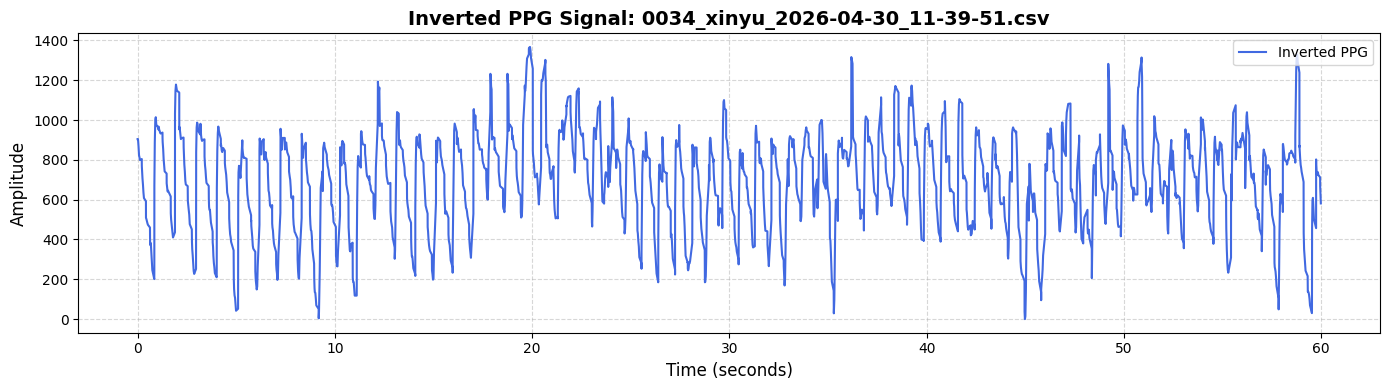

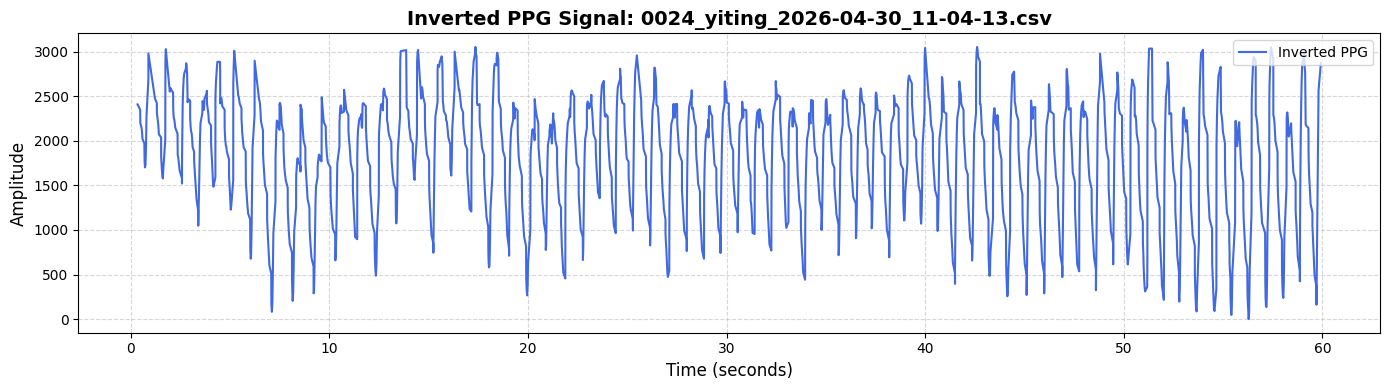

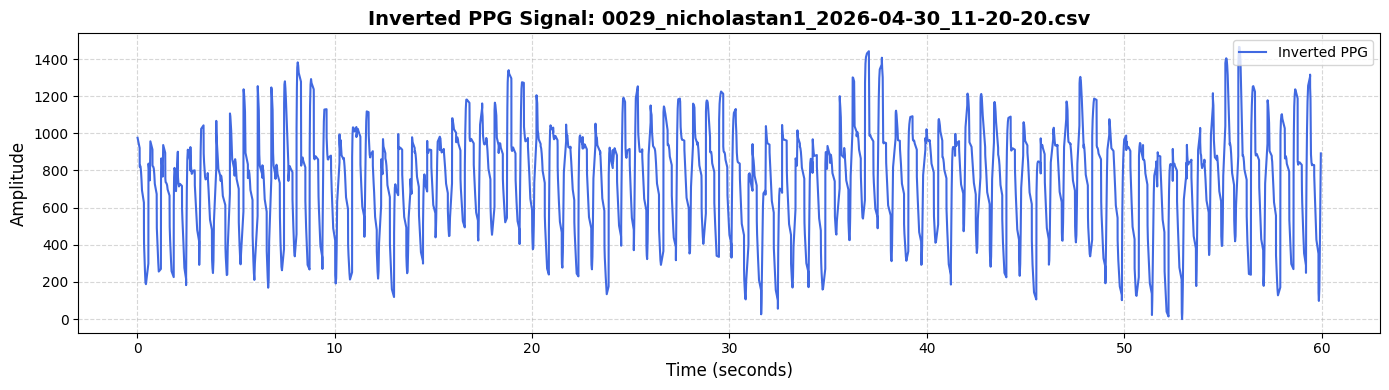

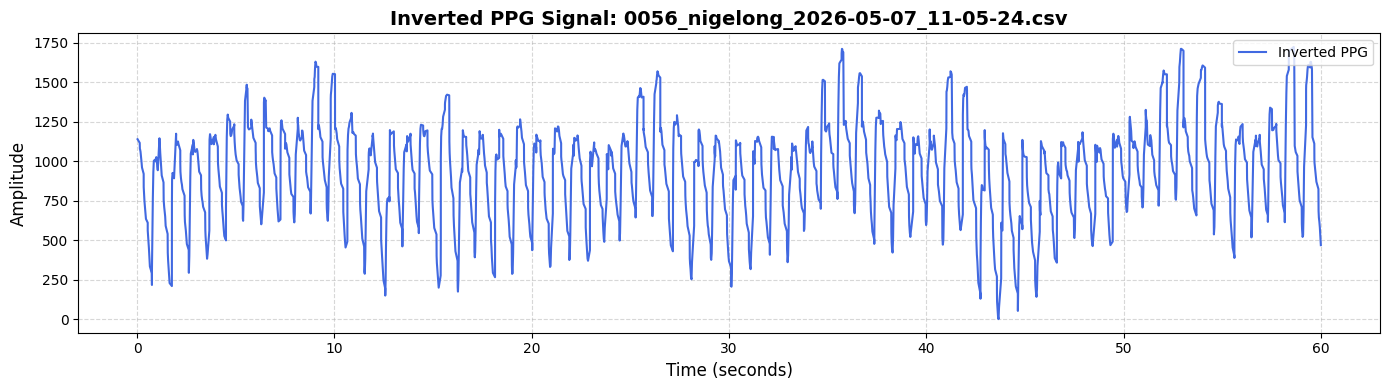

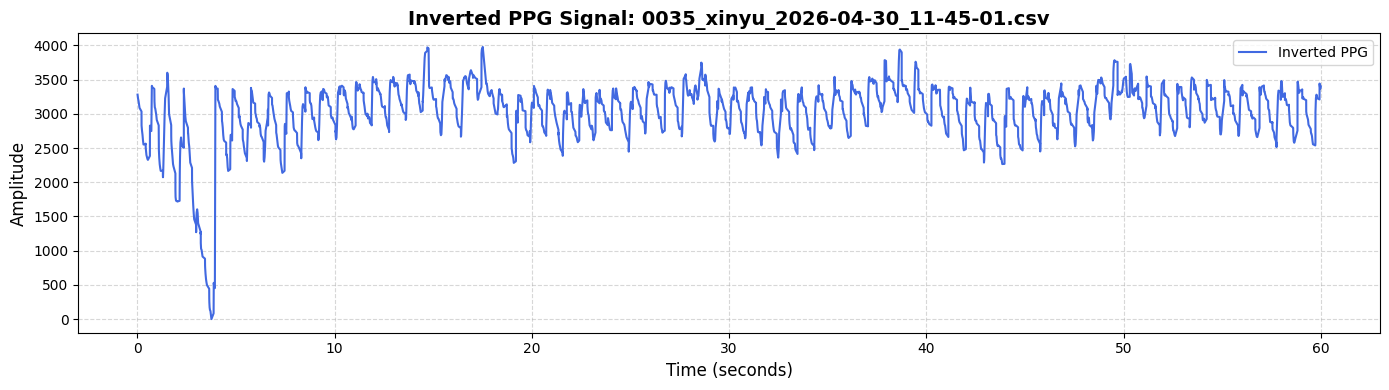

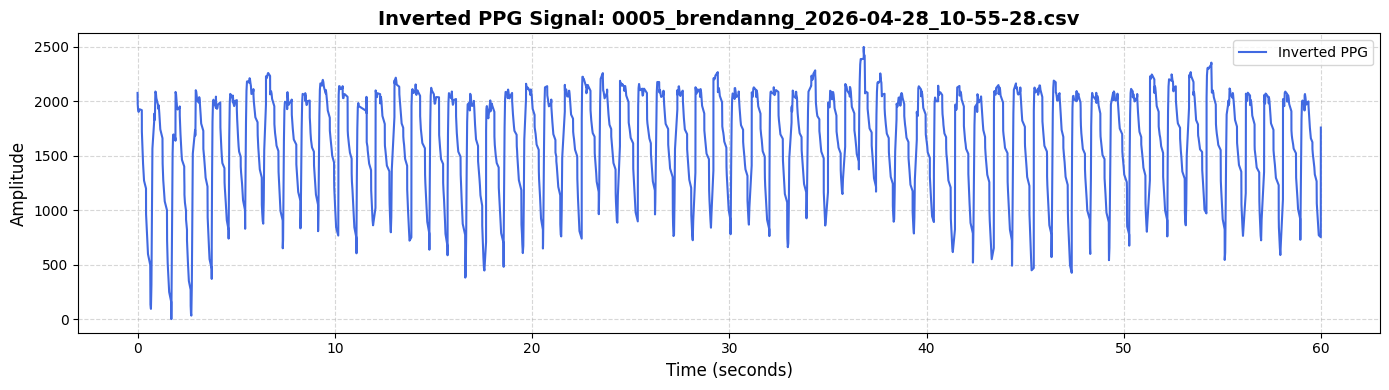

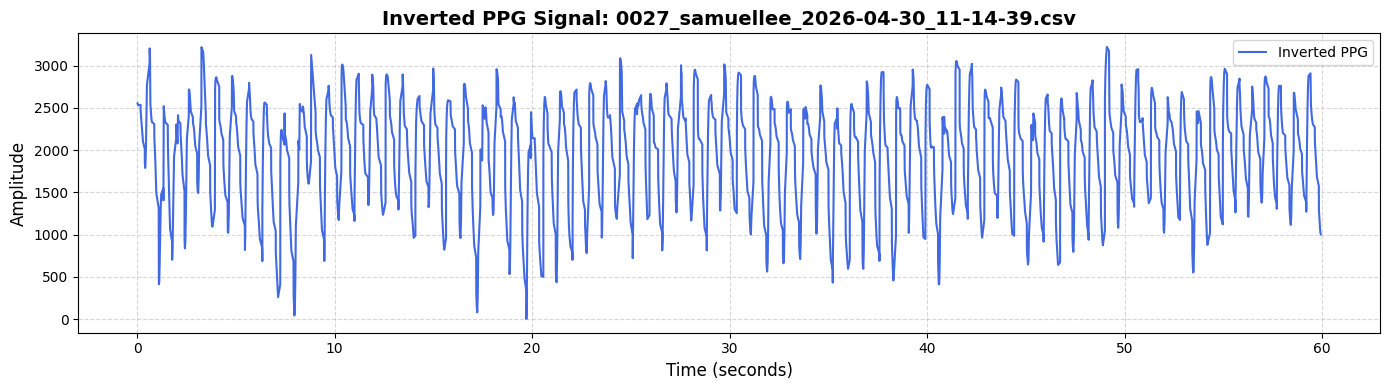

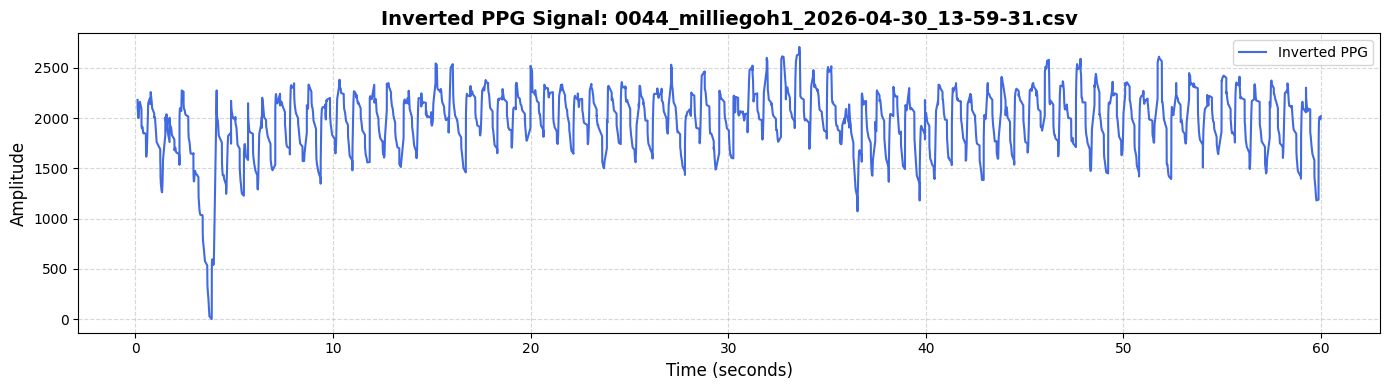

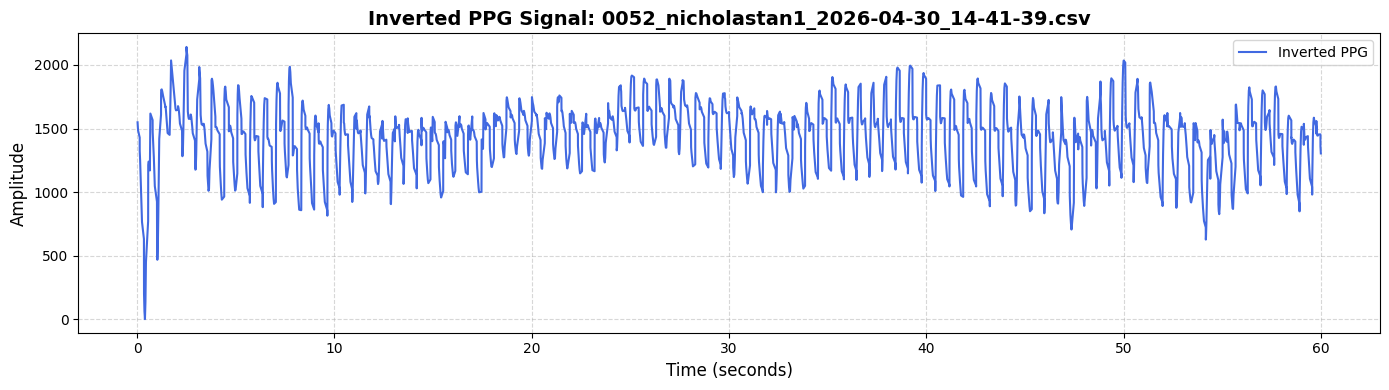

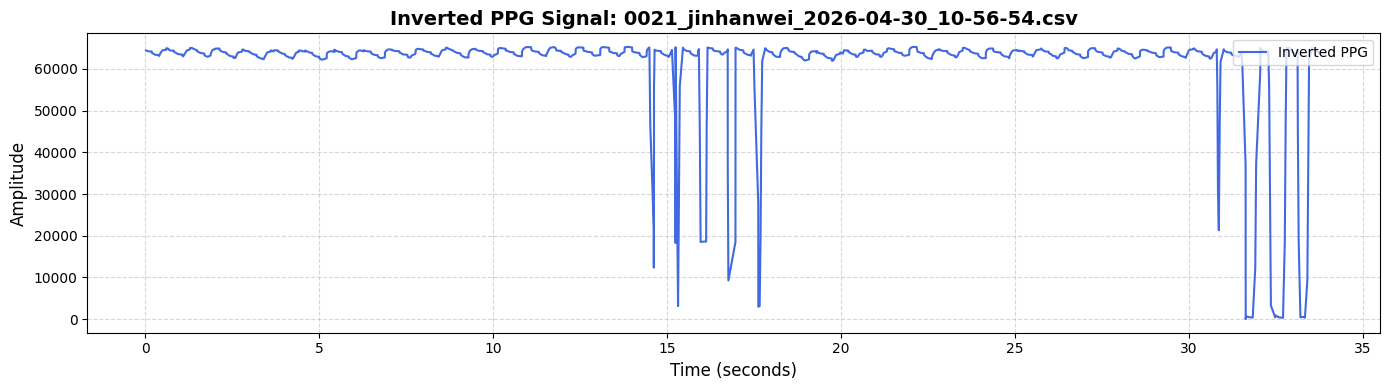

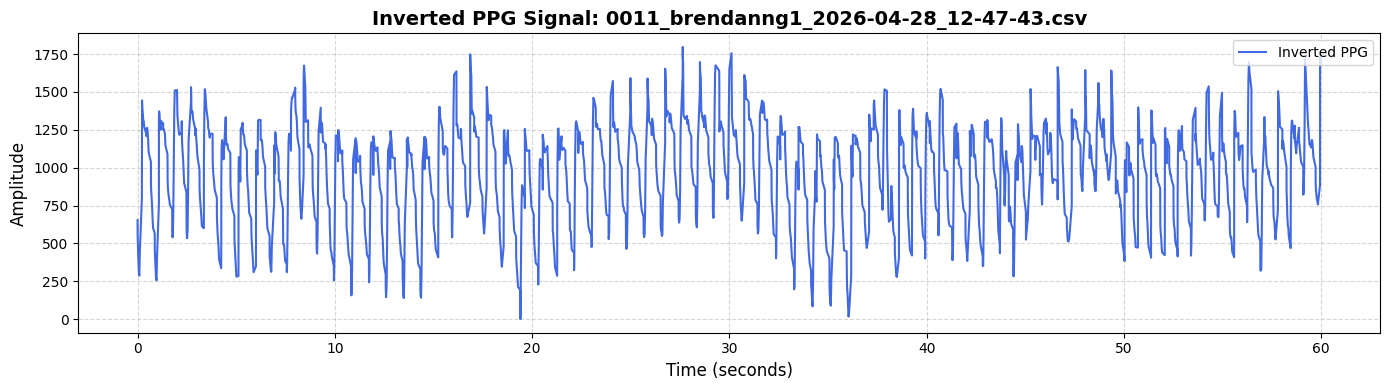

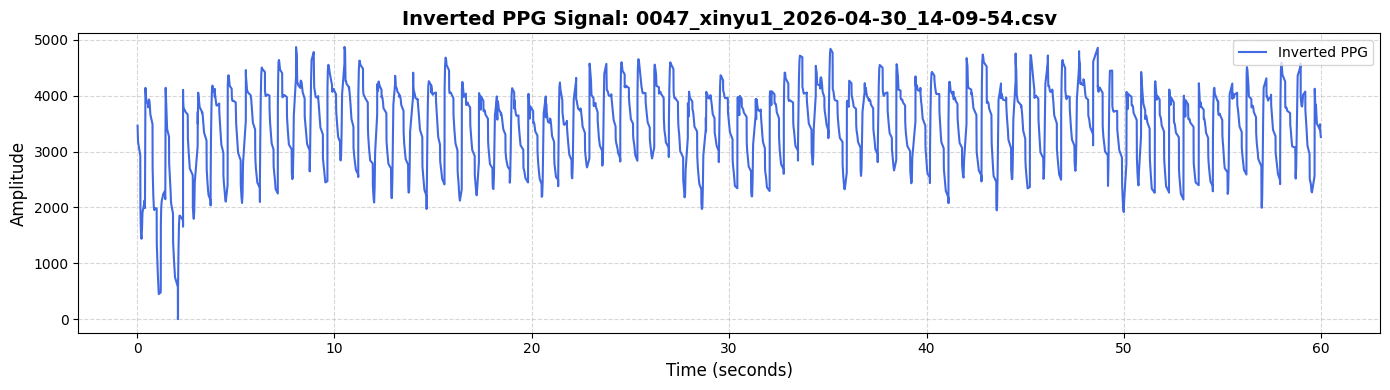

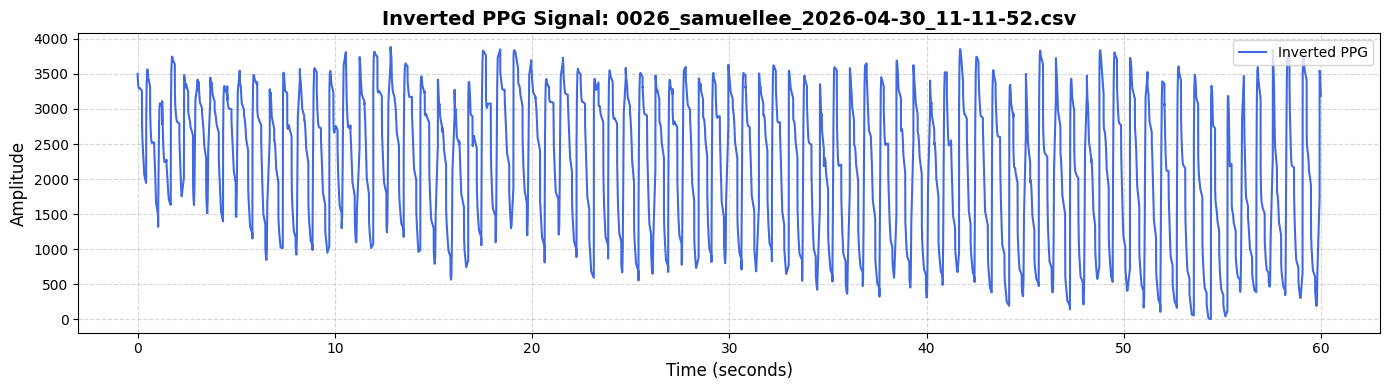

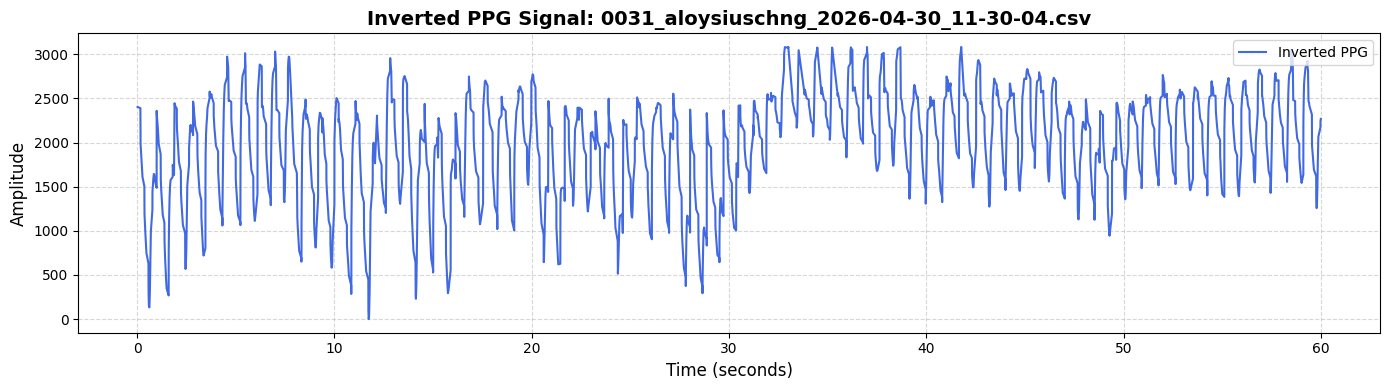

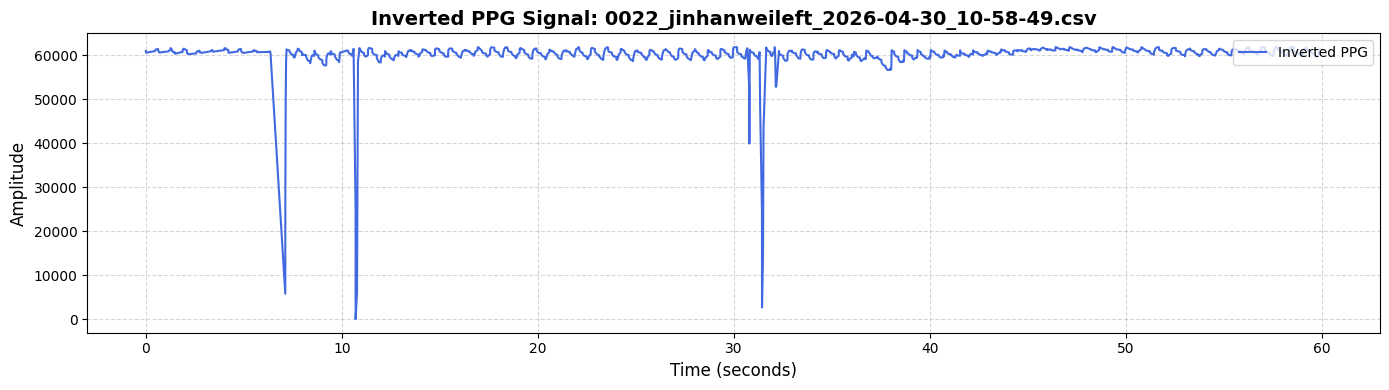

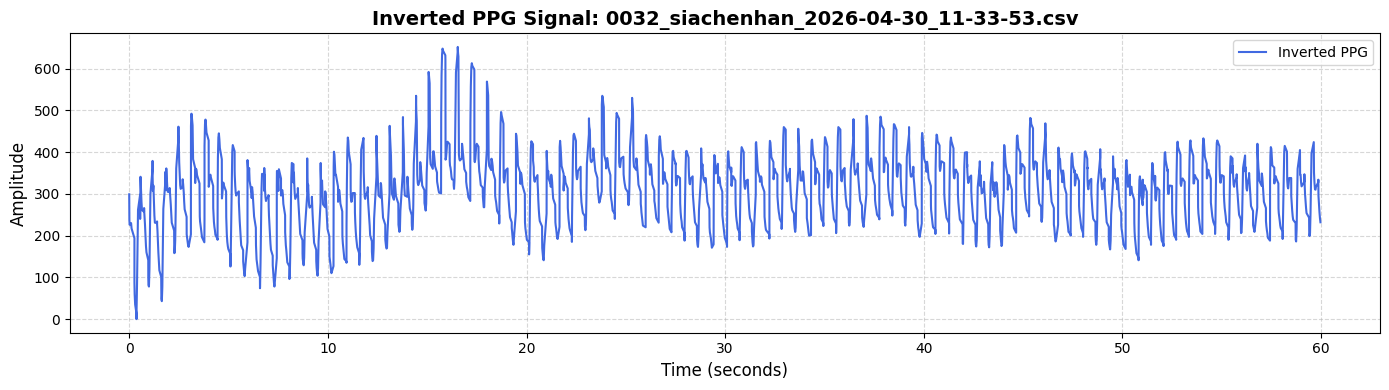

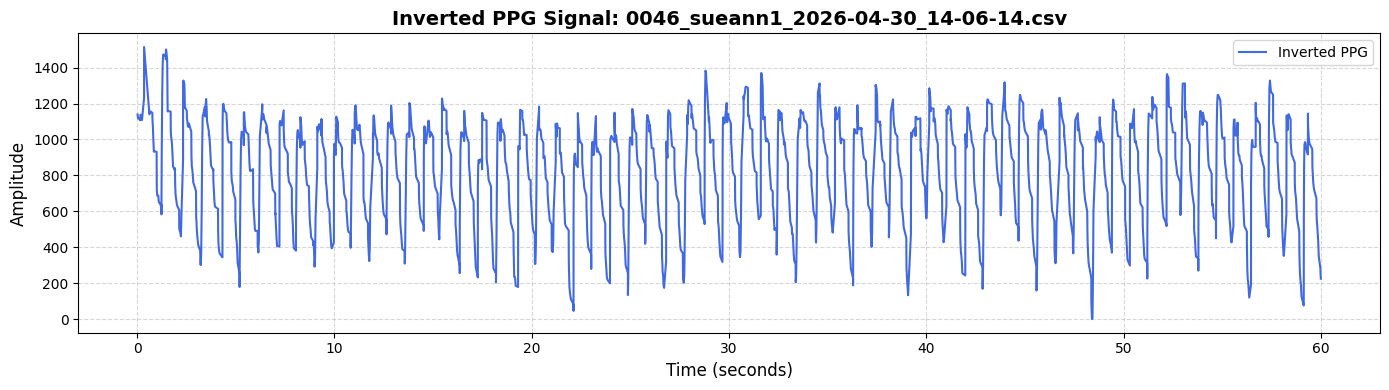

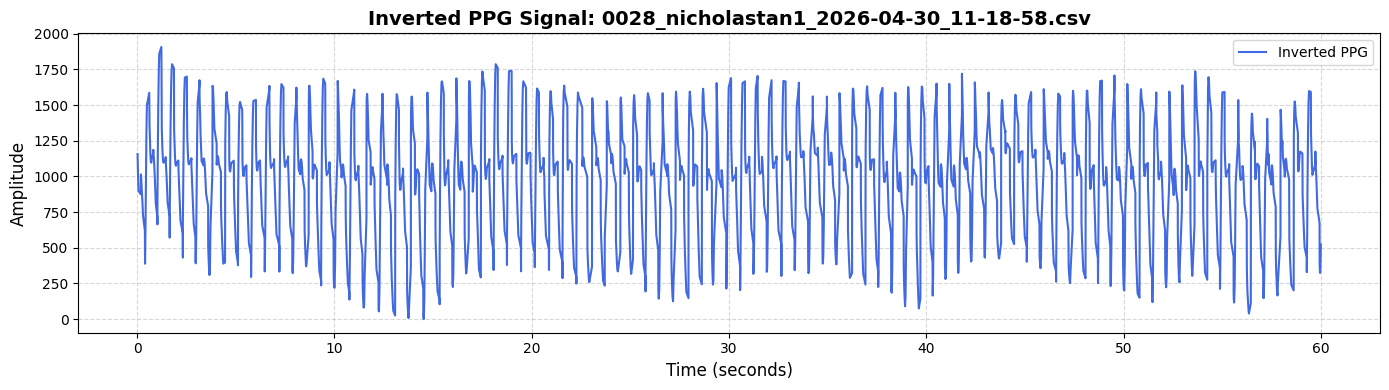

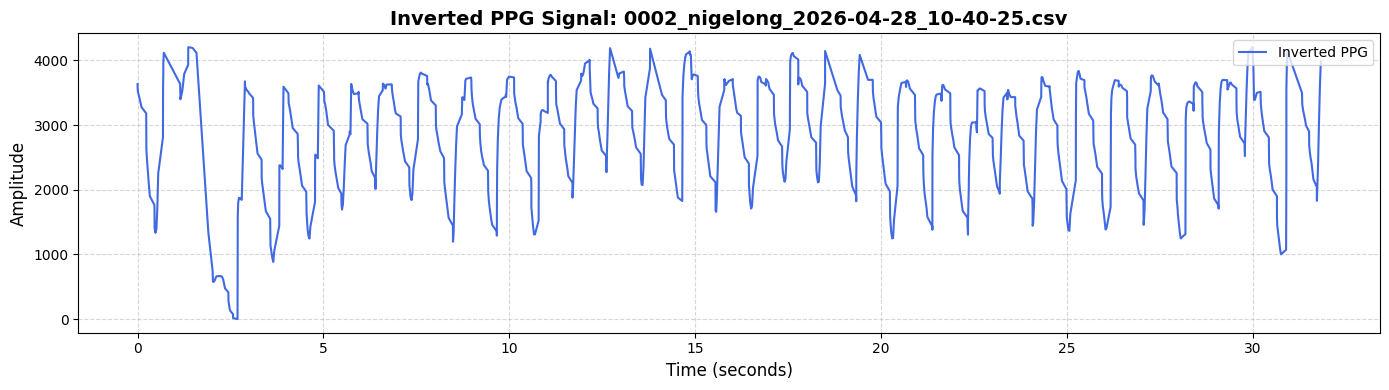

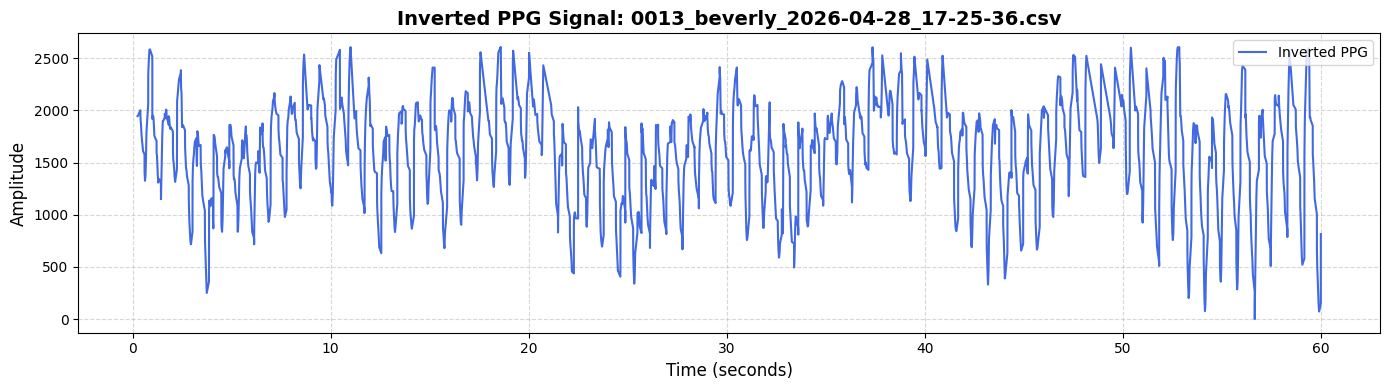

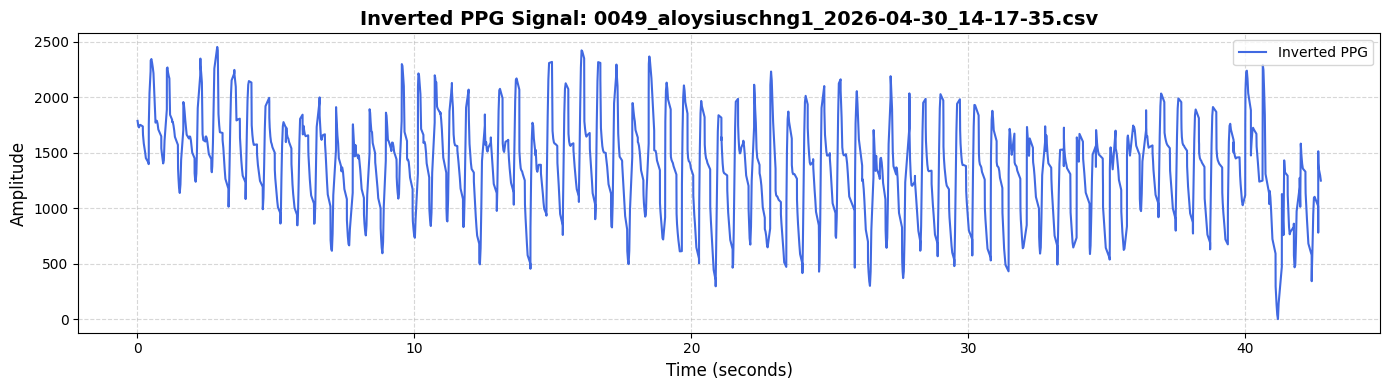

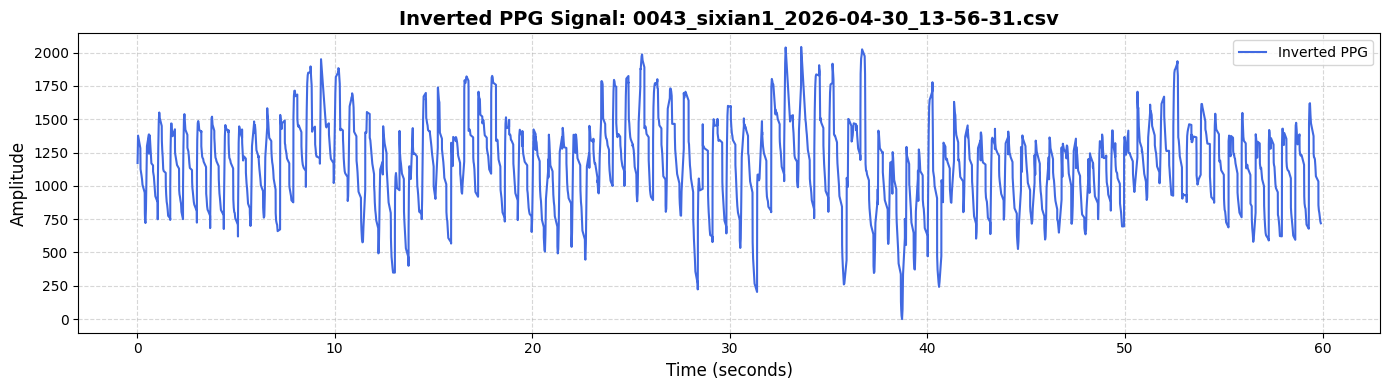

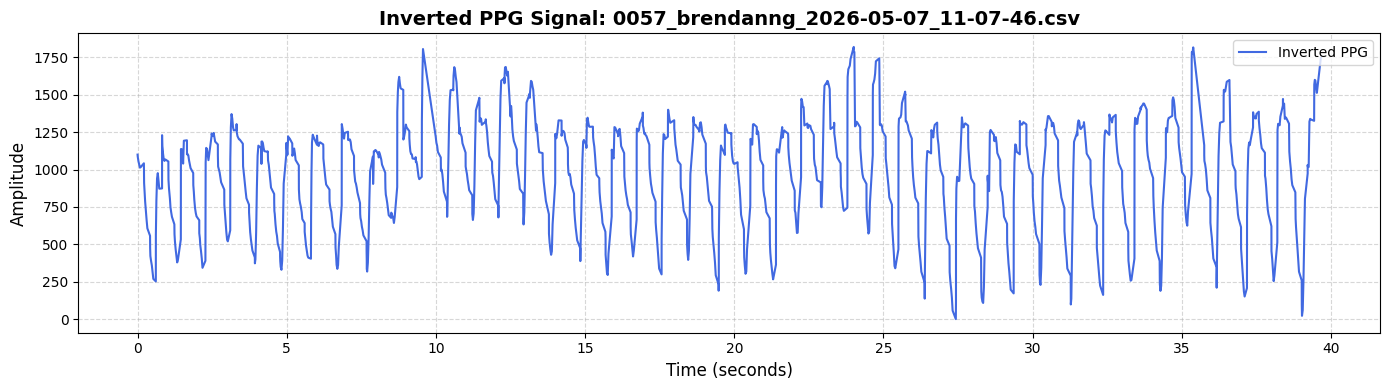

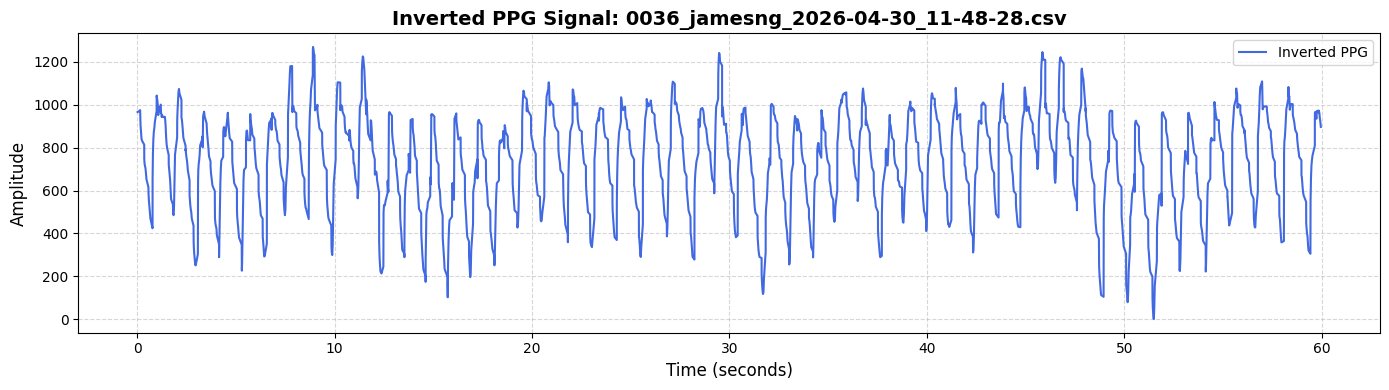

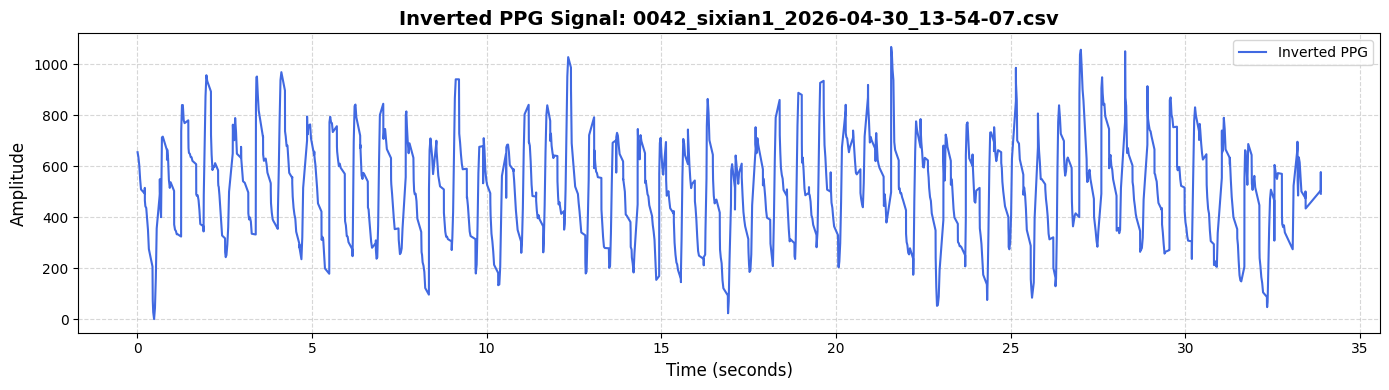

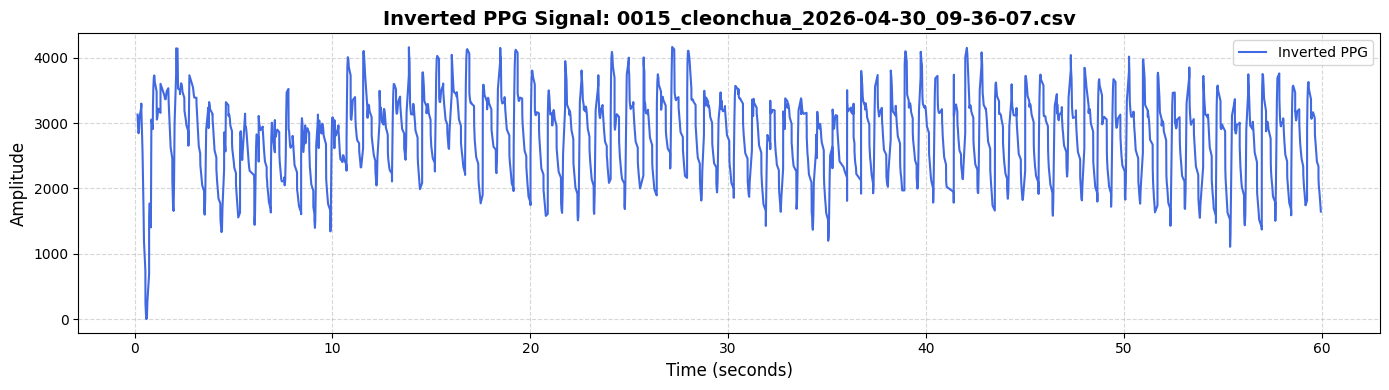

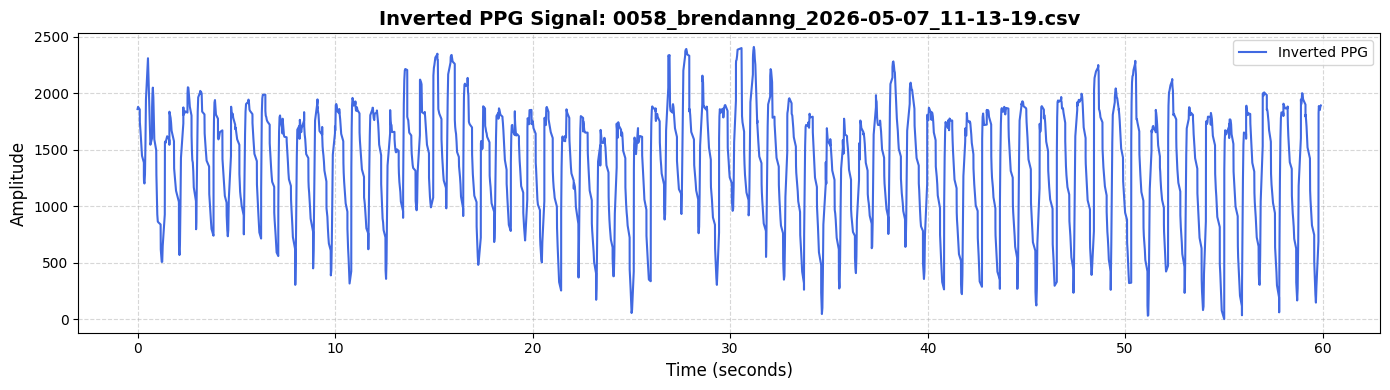

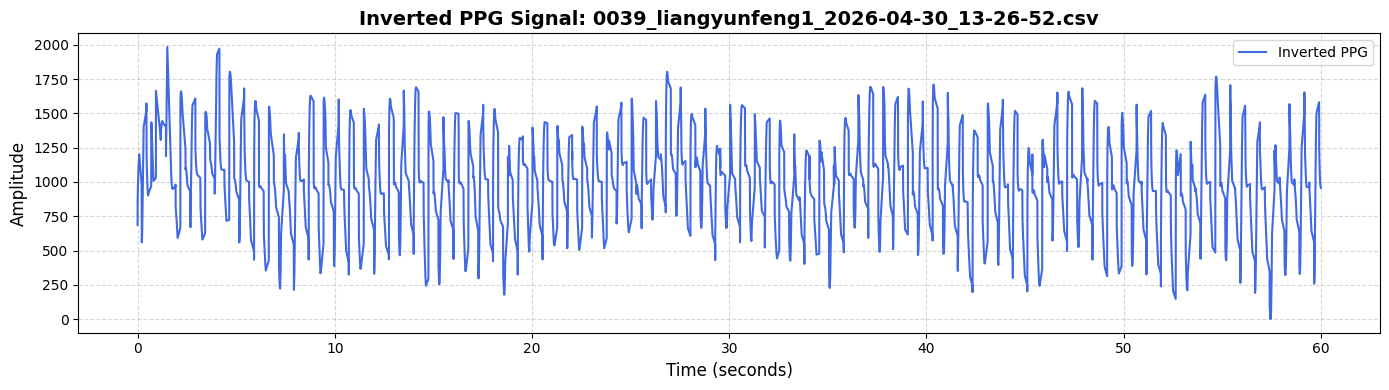

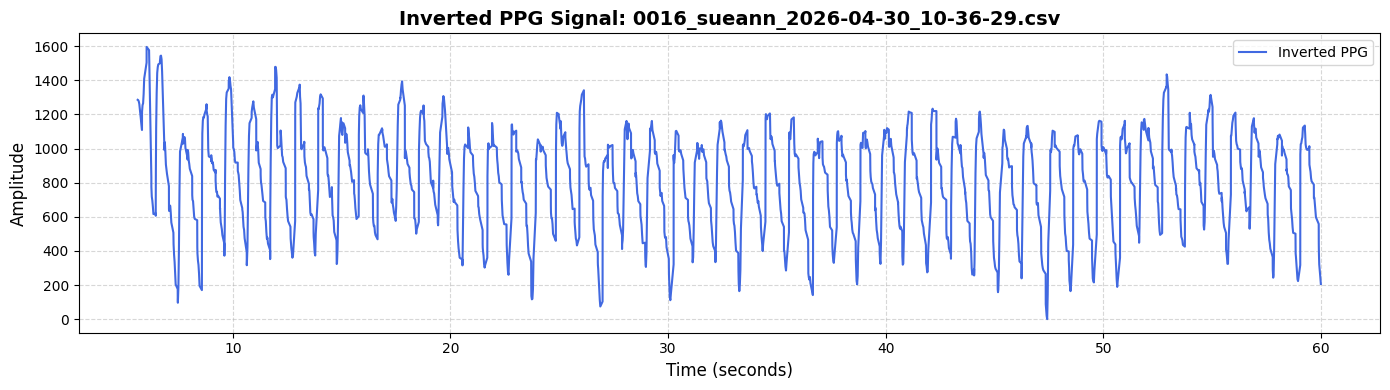

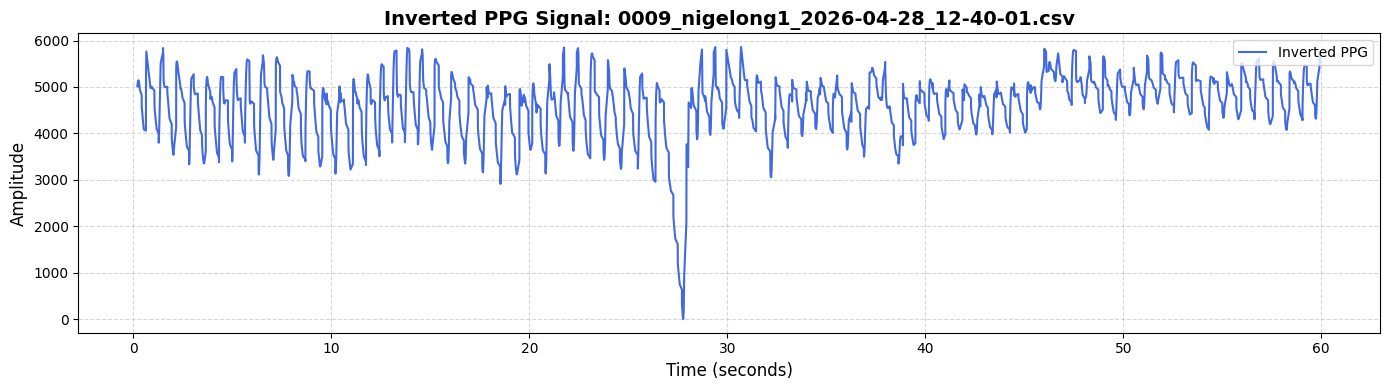

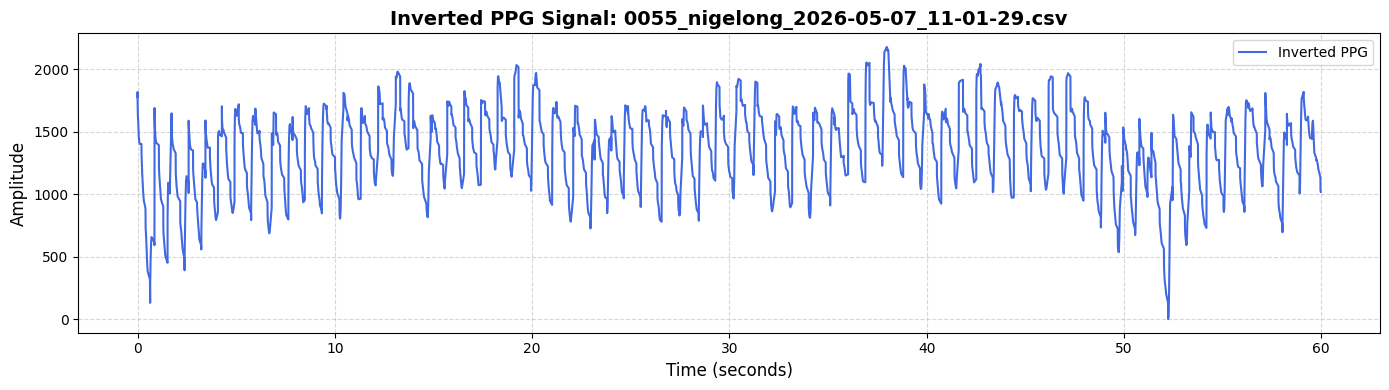

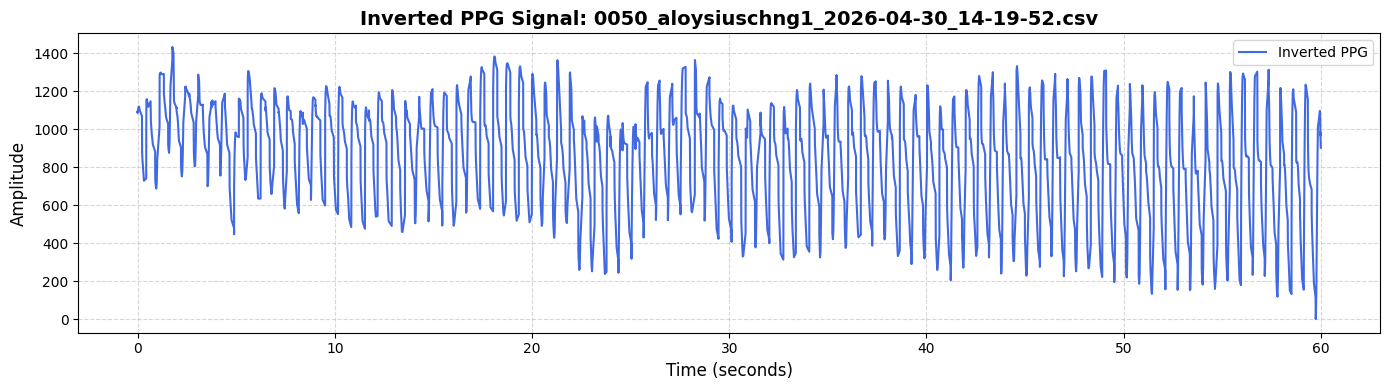

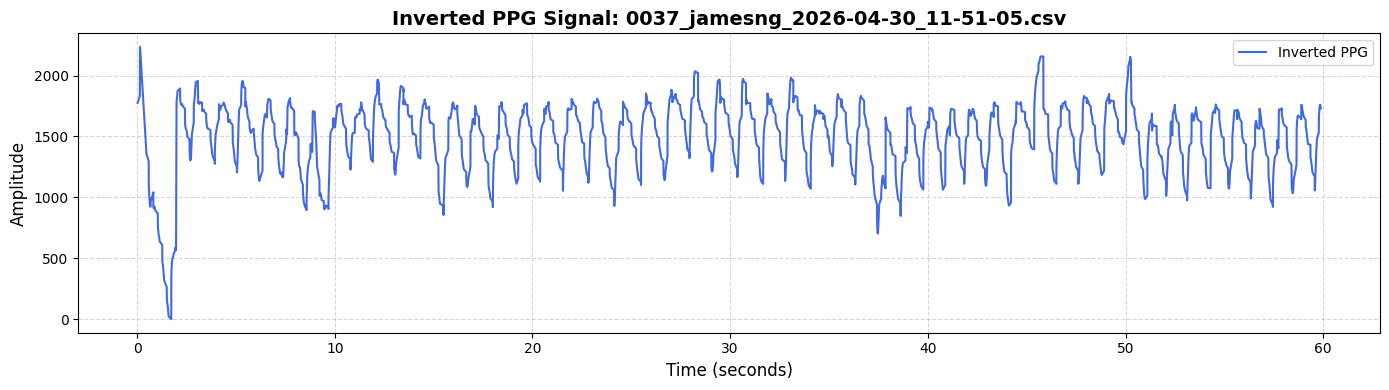

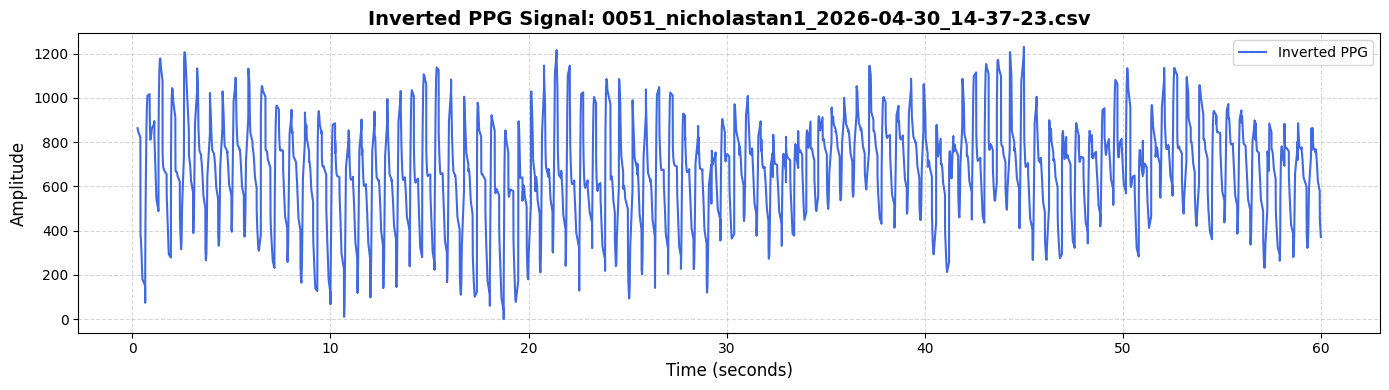

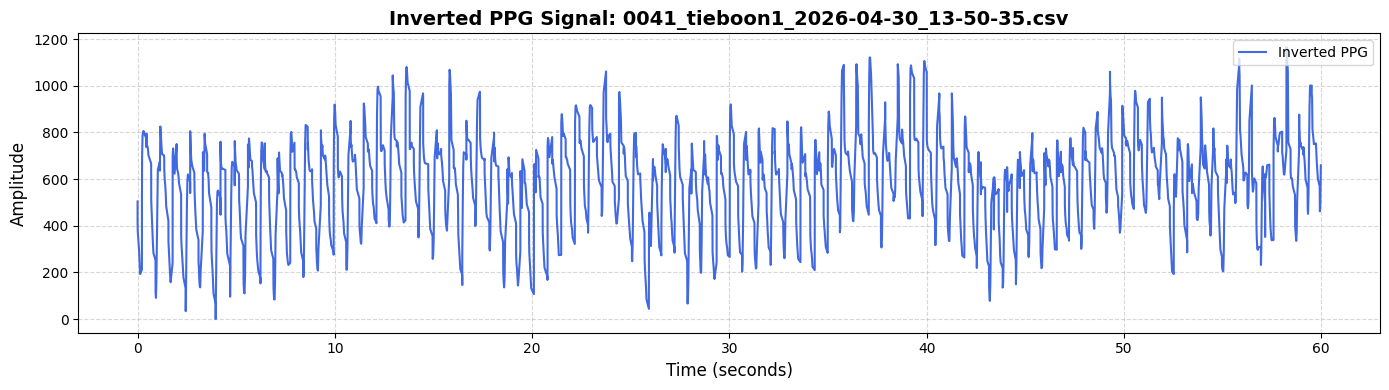

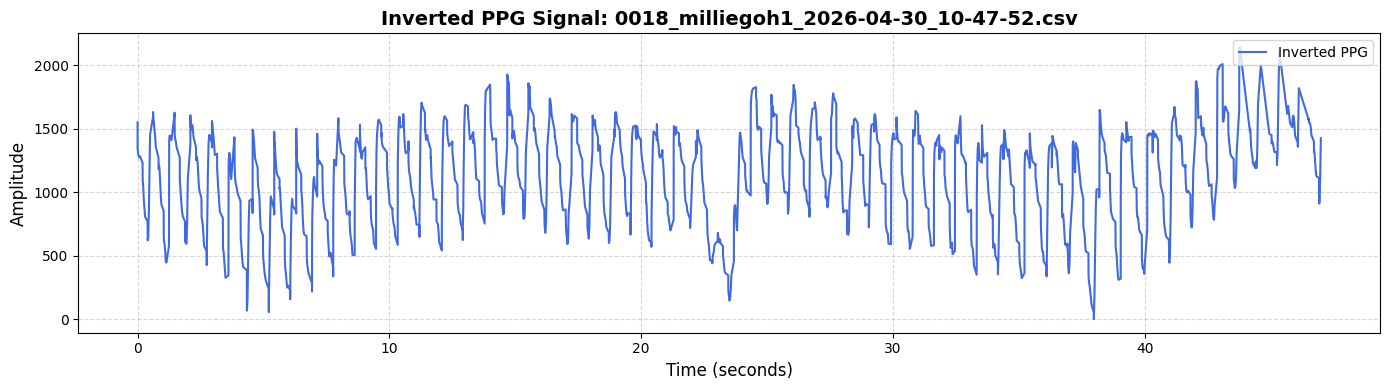

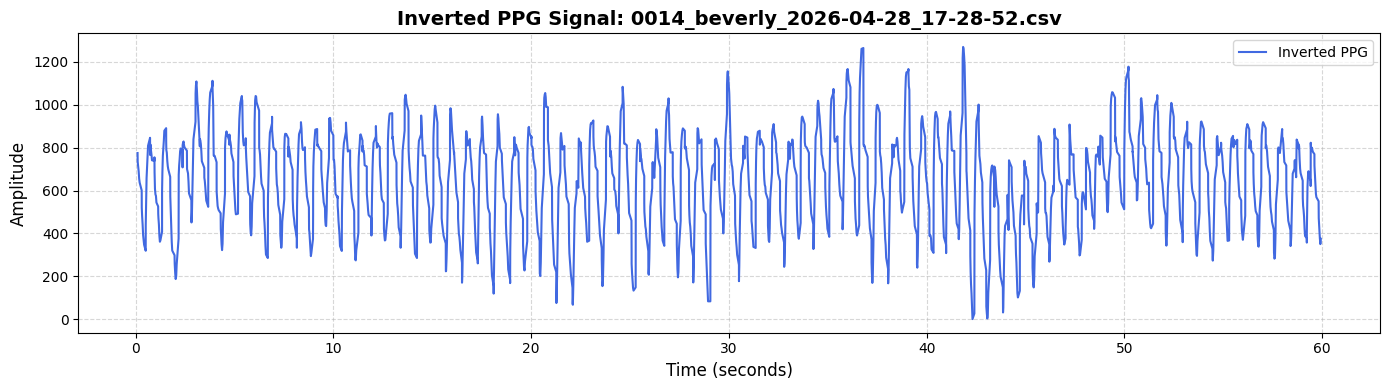

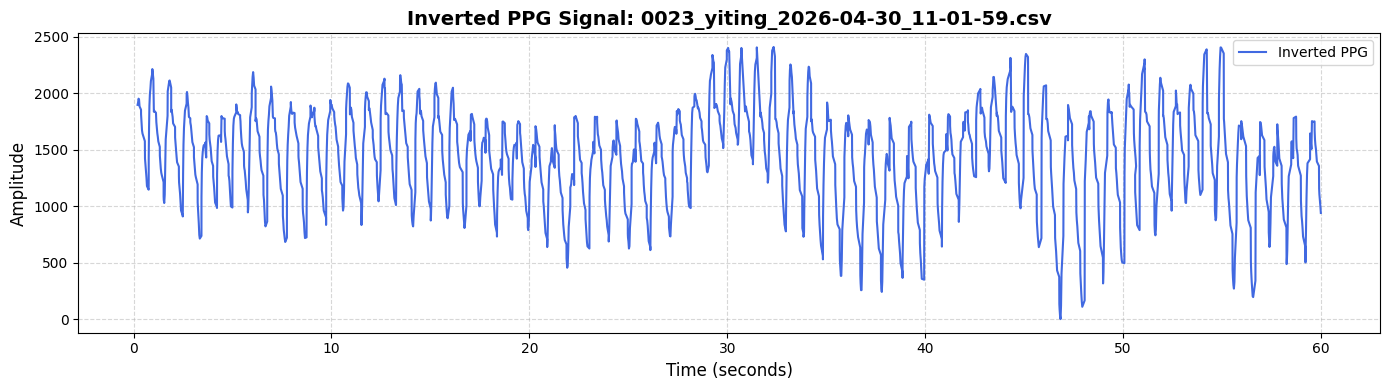

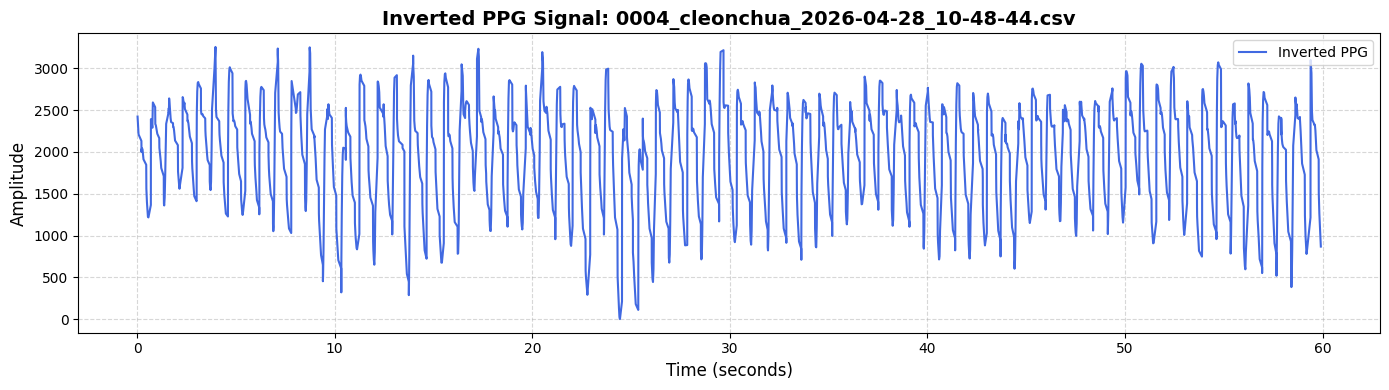

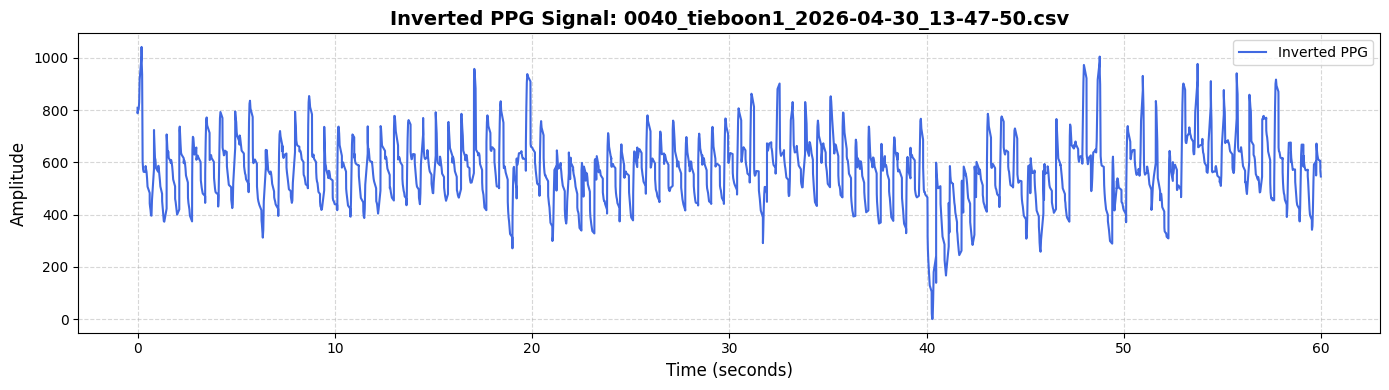

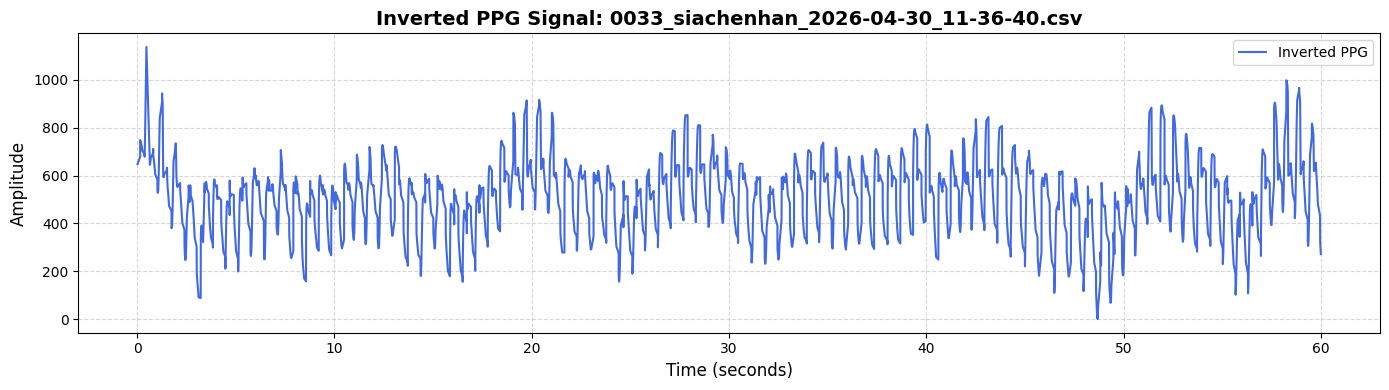

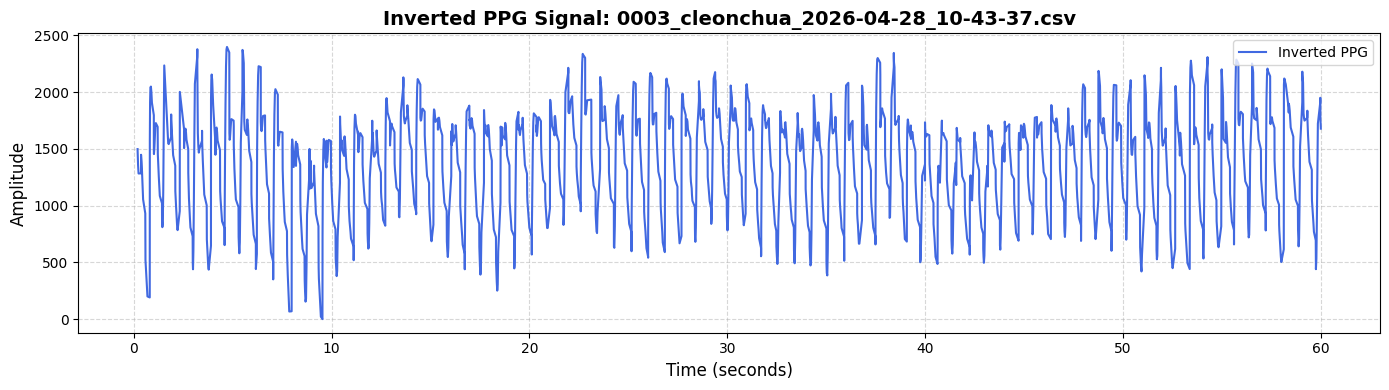

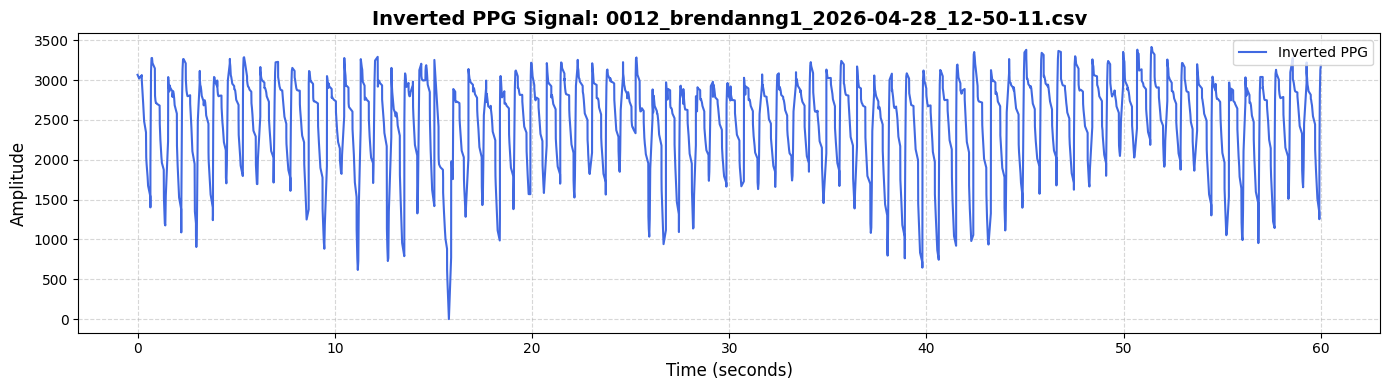

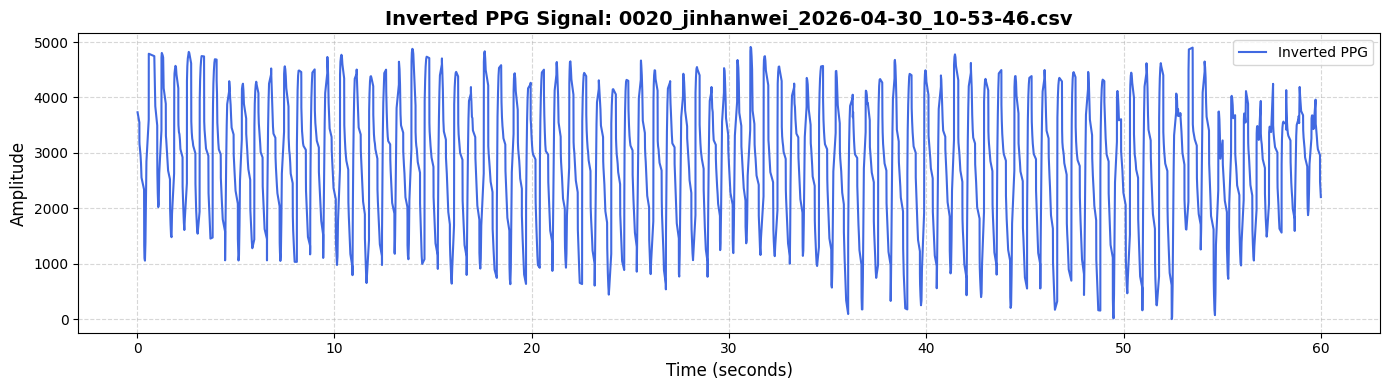

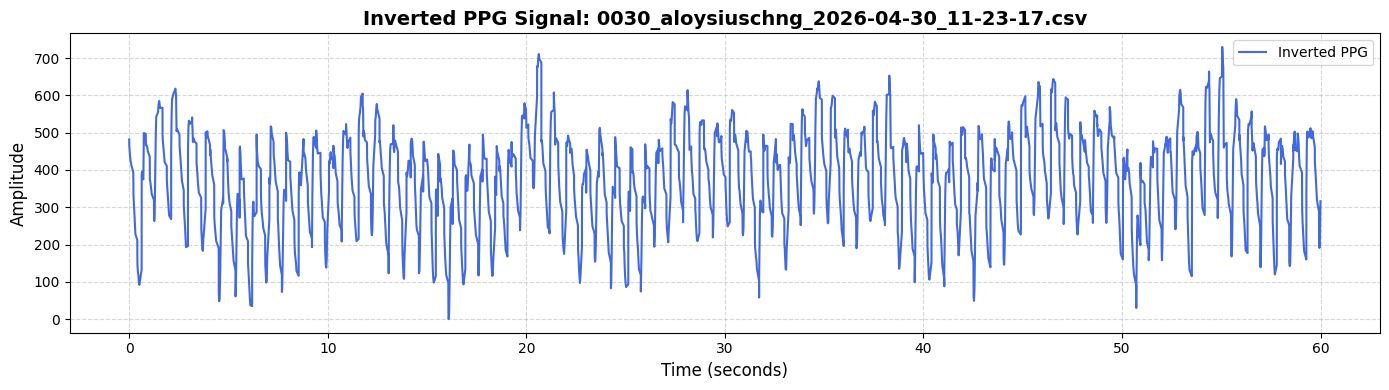

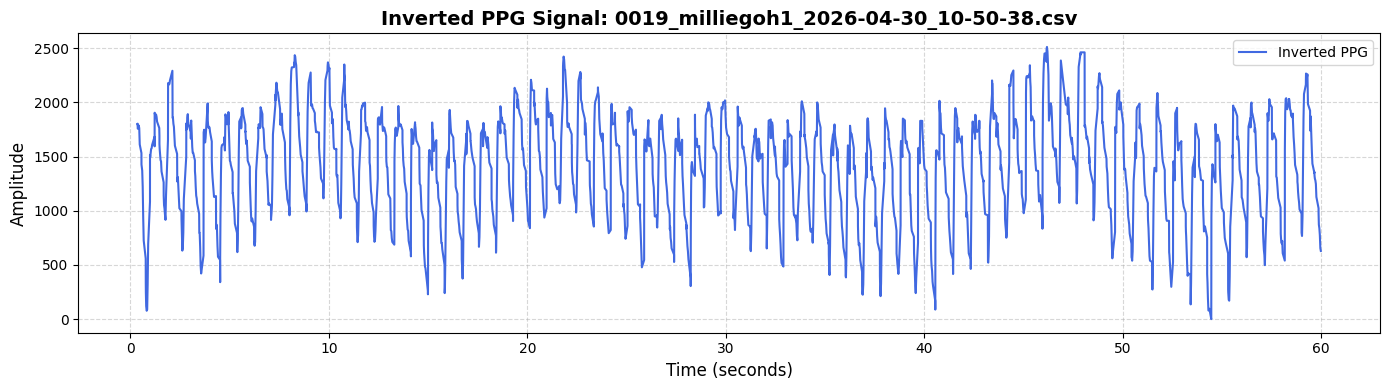

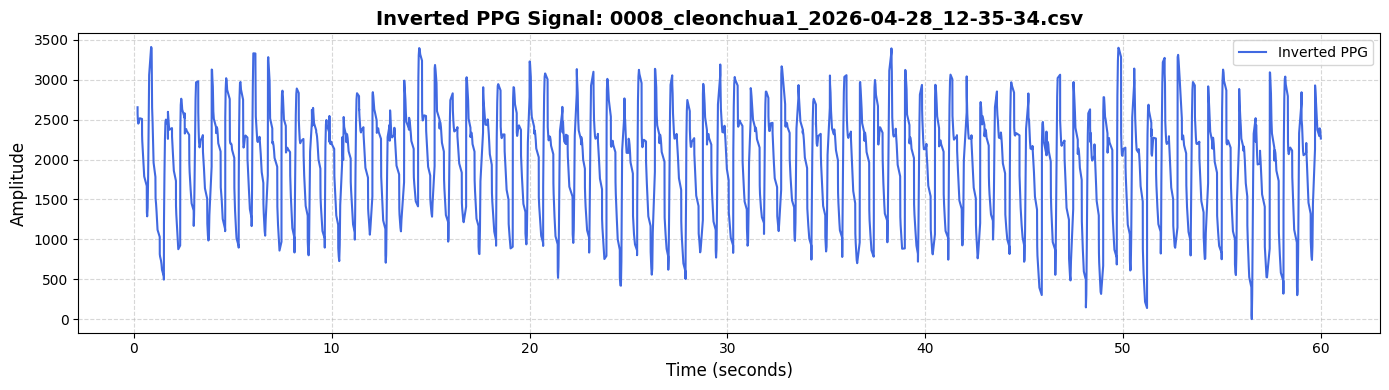

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# Define the path to your recordings folder
folder_path = './recordings/' # Update this if your path is different
csv_files = glob.glob(os.path.join(folder_path, '*.csv'))

if not csv_files:
    print(f"No CSV files found in {folder_path}. Please check the path.")
else:
    print(f"Found {len(csv_files)} file(s). Generating plots...")

    # Iterate through all found CSV files
    for file in csv_files:
        # Extract filename for the plot title
        file_name = os.path.basename(file)
        
        # Read the CSV, ignoring the commented metadata lines
        # 'timestamp_s' and 'ppg_raw' will automatically become our columns
        try:
            df = pd.read_csv(file, comment='#')
            
            # Basic Invert: Subtract raw signal from its maximum value
            # Alternatively, you could just use: df['ppg_inverted'] = -df['ppg_raw']
            max_val = df['ppg_raw'].max()
            df['ppg_inverted'] = max_val - df['ppg_raw']
            
            # Set up the plot
            plt.figure(figsize=(14, 4))
            
            # Plot the inverted signal
            plt.plot(df['timestamp_s'], df['ppg_inverted'], color='royalblue', linewidth=1.5, label='Inverted PPG')
            
            # Styling the chart
            plt.title(f'Inverted PPG Signal: {file_name}', fontsize=14, fontweight='bold')
            plt.xlabel('Time (seconds)', fontsize=12)
            plt.ylabel('Amplitude', fontsize=12)
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.legend(loc='upper right')
            
            # Adjust layout and render inside the notebook
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"Could not process {file_name}. Error: {e}")